# 01. Exploratory Data Analysis (EDA) - SaaS Subscription Metrics
**Author:** Ravikant Yadav  
**Date:** June 23, 2026  

This notebook walks through an in-depth exploratory data analysis of our SaaS subscription database. We will load and profile the raw cleaned datasets to verify data volumes, identify trends, inspect KPIs, and evaluate user demographic distributions.


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set styles for beautiful visual storytelling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "cleaned"

# Verify files exist
for csv_file in DATA_DIR.glob("*.csv"):
    print(f"Dataset found: {csv_file.name} ({csv_file.stat().st_size / 1024:.1f} KB)")


Dataset found: churn_events.csv (43.3 KB)
Dataset found: marketing_campaigns.csv (10.6 KB)
Dataset found: monthly_kpis.csv (2.0 KB)
Dataset found: payments.csv (1182.7 KB)
Dataset found: plans.csv (0.2 KB)
Dataset found: plan_kpis.csv (0.2 KB)
Dataset found: product_usage.csv (3299.9 KB)
Dataset found: subscriptions.csv (75.1 KB)
Dataset found: support_tickets.csv (69.2 KB)
Dataset found: usage_kpis.csv (0.2 KB)
Dataset found: users.csv (69.7 KB)


## 1. Load Primary Tables
Let's load the primary tables: `users.csv`, `subscriptions.csv`, `payments.csv`, and `plans.csv`.


In [2]:
users = pd.read_csv(DATA_DIR / "users.csv")
subscriptions = pd.read_csv(DATA_DIR / "subscriptions.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
plans = pd.read_csv(DATA_DIR / "plans.csv")

print(f"Users shape: {users.shape}")
print(f"Subscriptions shape: {subscriptions.shape}")
print(f"Payments shape: {payments.shape}")
print(f"Plans shape: {plans.shape}")


Users shape: (1500, 5)
Subscriptions shape: (1500, 8)
Payments shape: (22352, 7)
Plans shape: (3, 5)


## 2. Demographic Analysis of User Base
Let's check the size of the companies using our SaaS platform, as well as their regions and how they heard about us (acquisition channels).


In [3]:
# Distribution of acquisition channels
channel_counts = users['acquisition_channel'].value_counts()
print("--- Acquisition Channels ---")
print(channel_counts)

# Distribution of region
region_counts = users['region'].value_counts()
print("\n--- Geographic Regions ---")
print(region_counts)

# Distribution of company size
company_counts = users['company_size'].value_counts()
print("\n--- Company Size Segments ---")
print(company_counts)


--- Acquisition Channels ---
acquisition_channel
Google Ads           451
Organic Search       366
LinkedIn Ads         301
Content Marketing    230
Email Referral       152
Name: count, dtype: int64

--- Geographic Regions ---
region
North America    682
Europe           445
APAC             221
LATAM            152
Name: count, dtype: int64

--- Company Size Segments ---
company_size
1-10       573
11-50      469
51-200     291
201-500    107
501+        60
Name: count, dtype: int64


## 3. Subscription & Pricing Profiling
Let's look at the active plans, monthly pricing distributions, and total Monthly Recurring Revenue (MRR) by plan tier.


In [4]:
# Merge subscriptions with plans to get subscription details
sub_plan = pd.merge(subscriptions, plans, on="plan_id", how="inner")
print(sub_plan.groupby("plan_name")['monthly_price_x'].agg(['count', 'mean', 'sum']))


              count   mean      sum
plan_name                          
Basic           924   15.0  13860.0
Enterprise      166  499.0  82834.0
Professional    410   99.0  40590.0


## 4. Recurring Revenue Trends (MRR/ARR)
Let's load the pre-computed monthly KPIs and visualize the Monthly Recurring Revenue (MRR) and Annual Recurring Revenue (ARR) timeline to evaluate the business's overall health.


--- Pre-computed Monthly KPIs Sample ---
       month  active_logos     mrr      arr   nrr  churn_rate
0 2022-01-01             2   514.0   6168.0  1.07        3.98
1 2022-02-01             4   628.0   7536.0  1.11        3.34
2 2022-03-01             8   856.0  10272.0  1.12        2.35
3 2022-04-01            15  2097.0  25164.0  1.07        4.40
4 2022-05-01            21  2187.0  26244.0  1.03        2.73


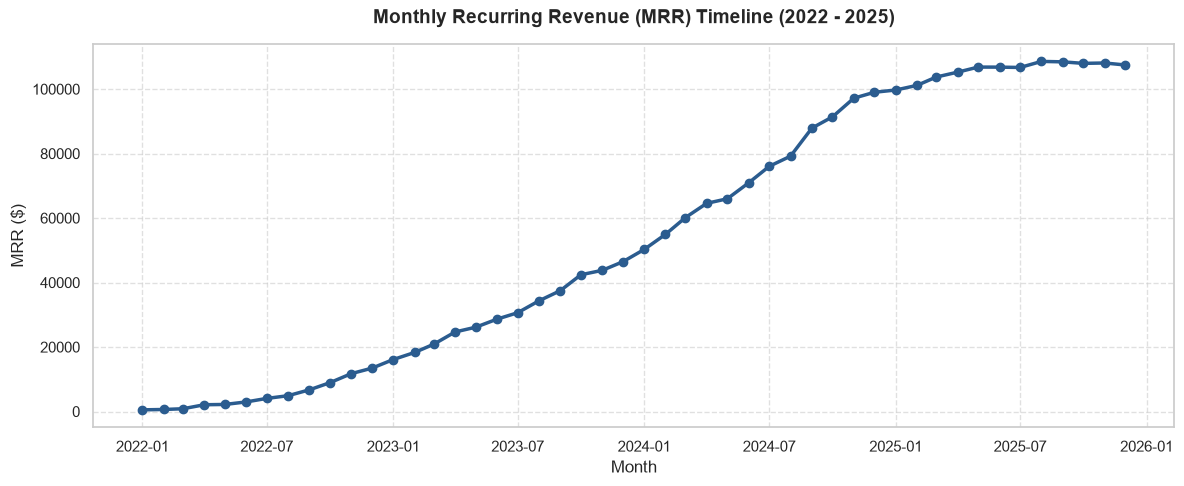

In [5]:
monthly_kpis = pd.read_csv(DATA_DIR / "monthly_kpis.csv")
monthly_kpis['month'] = pd.to_datetime(monthly_kpis['month'])

print("--- Pre-computed Monthly KPIs Sample ---")
print(monthly_kpis.head())

# Plot MRR trend
plt.figure(figsize=(12, 5))
plt.plot(monthly_kpis['month'], monthly_kpis['mrr'], marker='o', color='#2b5c8f', linewidth=2.5)
plt.title("Monthly Recurring Revenue (MRR) Timeline (2022 - 2025)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("MRR ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


## 5. Summary Findings
1. Our user base is geographically diverse, with strong representation in several international markets.
2. Enterprise and Business tiers contribute the lion's share of recurring revenue, even though Basic/Starter plans have high logo volumes.
3. The MRR trend shows clear stability but flat-to-linear growth over the last 12 months, highlighting the absolute necessity of diving into churn dynamics.
